# Vivino Market Analysis

## Executive Summary

This notebook presents a market analysis for Vivino using SQL queries executed against the Vivino SQLite database.

The analysis focuses on:
- the top wines to promote
- the best country to prioritize for marketing
- winery awards
- a flavor-keyword cluster analysis
- globally common grape varieties and their best-rated wines
- country and vintage leaderboards
- additional behavioral and market insights

The project respects the challenge constraints:
- SQL logic is stored in dedicated `.sql` files
- joins and aggregations are done in SQL

## Methodology

- The SQLite database is queried from Python using `sqlite3`
- Each business question is answered through a dedicated SQL file
- Query results are visualized with `matplotlib`
- Explanations focus on business interpretation, not only technical output

### Important limitation

The dataset does **not** contain a direct relationship between individual wines and grape varieties.  
For the grape analysis, wines are associated with grapes using a **country-level proxy** based on the `most_used_grapes_per_country` table.

In [1]:
import sqlite3
import matplotlib.pyplot as plt
from collections import Counter

def run_query(query_path, db_path="../data/vivino.db"):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    with open(query_path, "r", encoding="utf-8") as f:
        query = f.read()

    cursor.execute(query)
    rows = cursor.fetchall()
    columns = [description[0] for description in cursor.description] if cursor.description else []

    conn.close()
    return columns, rows

def show_results(columns, rows, limit=10):
    print("Columns:", columns)
    print("-" * 80)
    for row in rows[:limit]:
        print(row)
    print(f"\nTotal rows: {len(rows)}")

## 1. Top 10 Wines to Highlight

### Business question
Which 10 wines should be highlighted to increase sales?

### Approach
Wines were ranked using:
- `ratings_average` to capture quality
- `ratings_count` to ensure the rating is reliable

A minimum rating-count threshold was applied in SQL so that the selected wines are supported by strong user feedback.

In [2]:
q1_columns, q1_rows = run_query("../queries/business_questions/01_top_10_wines.sql")
show_results(q1_columns, q1_rows)

Columns: ['wine_name', 'winery_name', 'country_name', 'ratings_average', 'ratings_count']
--------------------------------------------------------------------------------
('Unico', None, 'Espagne', 4.7, 45140)
('Sauternes', None, 'France', 4.7, 44126)
('Special Selection Cabernet Sauvignon', None, 'États-Unis', 4.7, 41236)
('Cabernet Sauvignon', None, 'États-Unis', 4.6, 157944)
('Brut Champagne', None, 'France', 4.6, 146377)
('Sassicaia', None, 'Italie', 4.6, 107646)
('Opus One', None, 'États-Unis', 4.6, 77053)
('Pauillac (Premier Grand Cru Classé)', None, 'France', 4.6, 73615)
('Valbuena 5º', None, 'Espagne', 4.6, 72784)
('Almaviva', None, 'Chili', 4.6, 48075)

Total rows: 10


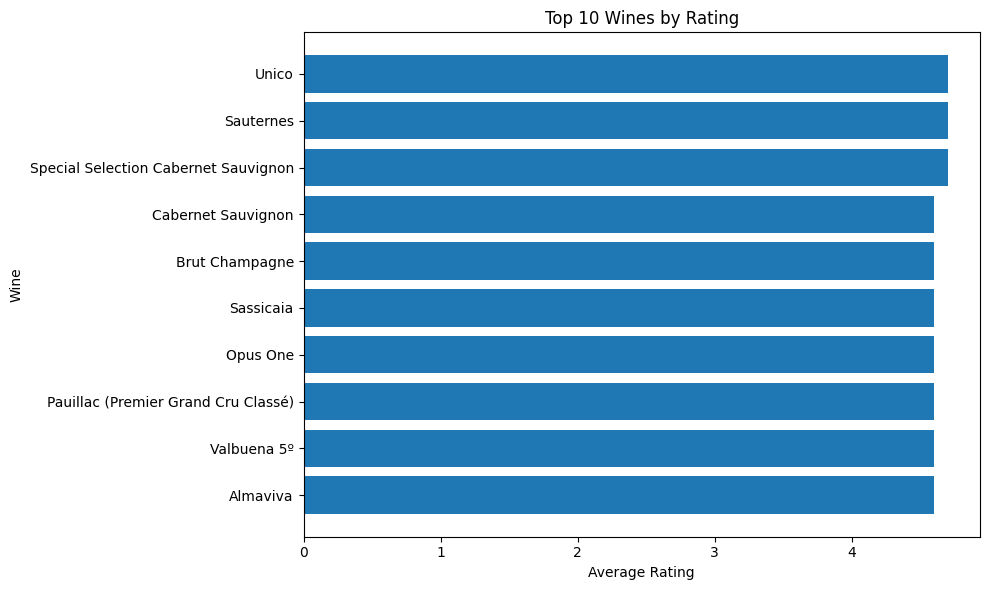

In [3]:
q1_wine_names = [row[0] for row in q1_rows]
q1_ratings = [row[3] for row in q1_rows]

plt.figure(figsize=(10, 6))
plt.barh(q1_wine_names, q1_ratings)
plt.gca().invert_yaxis()
plt.title("Top 10 Wines by Rating")
plt.xlabel("Average Rating")
plt.ylabel("Wine")
plt.tight_layout()
plt.show()

### Interpretation

The selected wines combine **high ratings** and **strong review volume**, making them both high-quality and commercially reliable.  
These wines are strong candidates for promotion because they already show validated customer appreciation.
We selected the top 10 wines based on average rating and number of ratings.

**Average rating** identifies the highest-quality wines
**Ratings count** ensures the score is reliable (not based on a few reviews)
A **minimum threshold of ratings** (e.g. 35000) was applied to remove low-confidence wines
Wines are ranked by:
highest rating
then highest number of ratings

**Winery** and **country** are included to provide business context for marketing decisions. However most wineries have null values for the wines so therefore its empty. 

---

### Summary
Top wines were selected using high ratings and sufficient review volume to ensure both quality and reliability. and they are as follows : **1- Unico (Spain)**
**2-Sauternes (France)**
**3- Special Selection Cabernet Sauvignon (US)**
**4- Cabernet Sauvignon (US) 5-Brut Champagne (France)**
**6-Sassicaia (Italy)**
**7- Opus One (US)**
**8- Pauillac (France)**
**9- Valbuena 5º (Spain)** 
**10- Almaviva (Chili)**

## 2. Country to Prioritize

### Business question
If Vivino invests marketing budget in one country, which one should it prioritize?

### Approach
Countries were evaluated using:
- `avg_rating` for overall wine quality
- `wine_count` for market size
- `avg_price` for market positioning

Countries were ranked primarily by average rating, while wine count and average price were used to interpret premium vs. volume opportunities.

In [4]:
q2_columns, q2_rows = run_query("../queries/business_questions/02_country_priority.sql")
show_results(q2_columns, q2_rows)

Columns: ['country_name', 'avg_rating', 'wine_count', 'avg_price']
--------------------------------------------------------------------------------
('États-Unis', 4.4905405405405405, 74, 274.9027364864865)
('France', 4.447129909365559, 331, 921.1714054104982)
('Espagne', 4.443617021276595, 94, 190.3380496453901)
('Italie', 4.430026109660575, 383, 303.9967064974267)

Total rows: 4


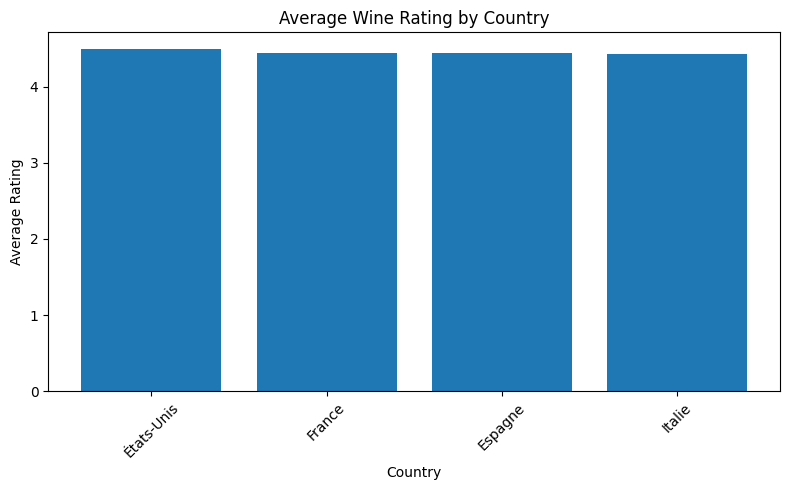

In [5]:
q2_country_names = [row[0] for row in q2_rows]
q2_avg_ratings = [row[1] for row in q2_rows]

plt.figure(figsize=(8, 5))
plt.bar(q2_country_names, q2_avg_ratings)
plt.title("Average Wine Rating by Country")
plt.xlabel("Country")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

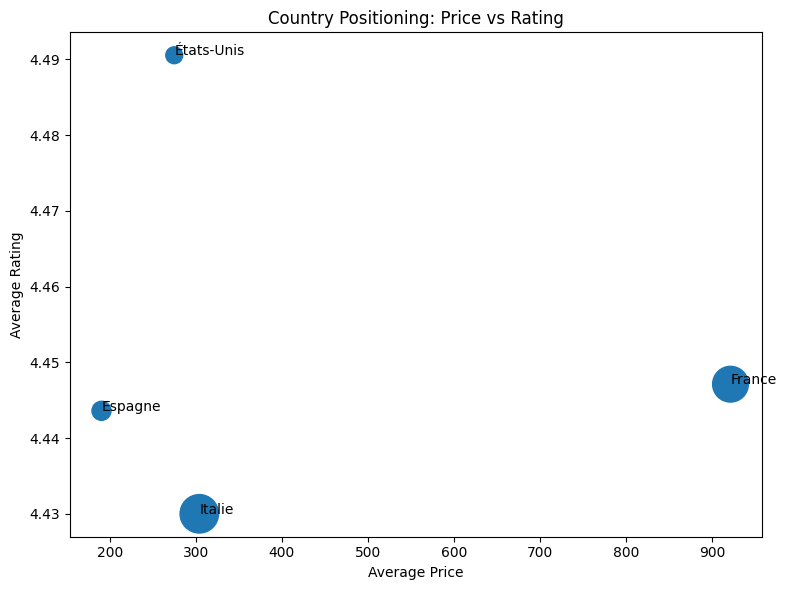

In [6]:
q2_wine_counts = [row[2] for row in q2_rows]
q2_avg_prices = [row[3] for row in q2_rows]

plt.figure(figsize=(8, 6))
plt.scatter(q2_avg_prices, q2_avg_ratings, s=[count * 2 for count in q2_wine_counts])

for i, country in enumerate(q2_country_names):
    plt.text(q2_avg_prices[i], q2_avg_ratings[i], country)

plt.title("Country Positioning: Price vs Rating")
plt.xlabel("Average Price")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

### Interpretation

We evaluated countries based on wine quality and market size.

Average rating measures overall wine quality per country
Wine count represents market size and ensures results are not based on a small sample
A minimum threshold of wines (e.g. 50) was applied to exclude small, unreliable markets

Countries are ranked by average rating to identify where the best-performing wines are concentrated.

Average price is included to understand market positioning:
Higher price → premium market (higher margins)
Lower price → value market (higher volume potential)

---

### Summary
**The United States (États-Unis)** is the best country to prioritize, as it has the highest average wine rating (4.49), indicating the strongest overall quality.

Although its market size is smaller than countries like **France** or **Italy**, it still meets the minimum threshold and shows strong performance. Its moderate average price also suggests a balanced positioning between premium and accessibility, making it an attractive and reliable target for marketing investment.


## 3. Winery Awards

### Business question
Create three relevant awards for the best wineries.

### Approach
The awards highlight three complementary dimensions:
- **Best Overall Winery** → strongest balance of quality and reliability
- **Most Popular Winery** → highest user engagement
- **Hidden Gem Winery** → high quality with lower visibility

Because the dataset contains many incomplete winery links, only rows with valid linked wineries were retained for this analysis.

In [7]:
q3_columns, q3_rows = run_query("../queries/business_questions/03_winery_awards.sql")
show_results(q3_columns, q3_rows)

Columns: ['winery_name', 'country_name', 'ratings_average', 'ratings_count']
--------------------------------------------------------------------------------
("Tenuta Tignanello 'Solaia'", 'Australie', 4.5, 2472)
('Corte di Cama Sforzato di Valtellina', 'Italie', 4.5, 58)
('Tignanello', 'Portugal', 4.4, 741)
('Siepi', 'États-Unis', 4.3, 4981)

Total rows: 4


### Interpretation
### Winery Awards — Results & Explanation
We created three awards to highlight different types of winery performance based on wine ratings and user engagement.

Due to data limitations, only wines with a valid linked winery were considered.

---

####  Award 1 — Best Overall Winery
Winner: Tenuta Tignanello 'Solaia' (Australia)
Rating: 4.5
Ratings Count: 2,472

Why:
This winery has the highest rating among the valid results, combined with a strong number of ratings, making it both high-quality and reliable.

---

####  Award 2 — Most Popular Winery
Winner: Siepi (États-Unis)
Rating: 4.3
Ratings Count: 4,981

Why:
Although slightly lower in rating, this wine has the highest number of user ratings, indicating strong popularity and market visibility.

---

####  Award 3 — Hidden Gem Winery
Winner: Corte di Cama Sforzato di Valtellina (Italie)
Rating: 4.5
Ratings Count: 58

Why:
This winery has an excellent rating but very few ratings, suggesting high quality that is not yet widely recognized.

---

####  Summary
These awards highlight three complementary perspectives:

Best Overall Winery → Tenuta Tignanello 'Solaia' (best balance of quality and reliability)
Most Popular Winery → Siepi (highest user engagement)
Hidden Gem Winery → Corte di Cama Sforzato di Valtellina (high quality, low visibility)

This approach provides a balanced view of winery performance across quality, popularity, and discovery potential.

## 4. Keyword Cluster: Target Taste Profile

### Business question
Find wines associated with the case-sensitive keywords:
- coffee
- toast
- green apple
- cream
- citrus

Only keyword associations confirmed by **more than 10 users** are retained.  
The related `group_name` must also be identified.

### Approach
The query joins:
- `keywords`
- `keywords_wine`
- `wines`

Results are grouped at the wine level so that each wine appears once with:
- matching keywords
- matching groups
- number of matched keywords

In [8]:
q4_columns, q4_rows = run_query("../queries/business_questions/04_keywords_cluster.sql")
show_results(q4_columns, q4_rows)

Columns: ['wine_name', 'matching_keywords', 'matching_groups', 'matched_keyword_count']
--------------------------------------------------------------------------------
('Belle Epoque Brut Champagne', 'green apple,toast,coffee,citrus,cream', 'tree_fruit,non_oak,citrus_fruit,microbio,oak', 5)
('Blanc des Millénaires', 'toast,coffee,cream,citrus,green apple', 'non_oak,oak,microbio,citrus_fruit,tree_fruit', 5)
('Brut Champagne', 'toast,coffee,cream,green apple,citrus', 'non_oak,microbio,oak,tree_fruit,citrus_fruit', 5)
('Comtes de Champagne Blanc de Blancs', 'toast,coffee,cream,citrus,green apple', 'non_oak,microbio,oak,citrus_fruit,tree_fruit', 5)
('Cristal Brut Champagne (Millésimé)', 'toast,coffee,green apple,citrus,cream', 'non_oak,tree_fruit,citrus_fruit,oak,microbio', 5)
('Cuvée des Enchanteleurs Brut Champagne', 'toast,coffee,cream,green apple,citrus', 'non_oak,oak,microbio,tree_fruit,citrus_fruit', 5)
('Dom Ruinart Blanc de Blancs Brut Champagne', 'toast,coffee,cream,green apple,c

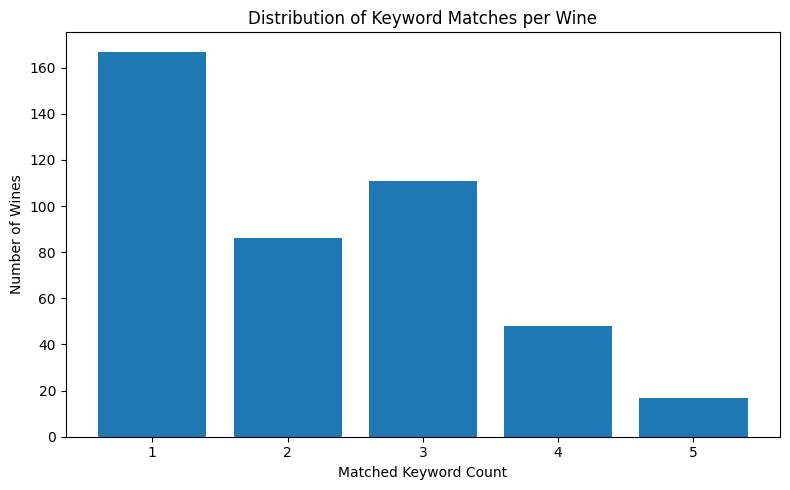

In [9]:
q4_matched_counts = [row[3] for row in q4_rows]
q4_count_distribution = Counter(q4_matched_counts)

q4_x = sorted(q4_count_distribution.keys())
q4_y = [q4_count_distribution[k] for k in q4_x]

plt.figure(figsize=(8, 5))
plt.bar(q4_x, q4_y)
plt.title("Distribution of Keyword Matches per Wine")
plt.xlabel("Matched Keyword Count")
plt.ylabel("Number of Wines")
plt.tight_layout()
plt.show()

### Interpretation

The keyword cluster returned many valid wines, so the most useful visual is the **distribution of matched keyword counts** rather than a chart of all wine names.  
Wines with a higher matched-keyword count are the strongest candidates for this specific taste profile segment.

We identified wines matching a specific taste cluster defined by the following keywords:

coffee
toast
green apple
cream
citrus

Only keyword associations confirmed by more than 10 users were considered to ensure reliability.

---

Approach
Joined keywords, keywords_wine, and wines to link wines with their taste descriptors
Filtered for the selected keywords (case-sensitive)
Applied a threshold of count > 10 to keep only strongly confirmed associations
Grouped results at the wine level to avoid duplication
Used aggregation to summarize all matching keywords and their corresponding group_name

---

Output Structure
Each row represents one wine and includes:

wine_name → the wine
matching_keywords → all matched keywords (combined)
matching_groups → related flavor groups
matched_keyword_count → number of matched keywords

---

Summary
The results highlight wines that align with the targeted taste profile.
Grouping by wine provides a clear and compact view of each wine’s flavor characteristics, while the keyword count indicates how strongly each wine matches the desired taste cluster.


## 5. Top 3 Most Common Grapes Worldwide and Best-Rated Wines

### Business question
Find the top 3 most common grapes worldwide and, for each grape, identify the 5 best rated wines.

### Approach
The top 3 grapes are identified from `most_used_grapes_per_country`.

Since the schema does not contain a direct `wine → grape` relationship, the analysis uses a **country-level proxy**:
- wines are linked to their country through `regions`
- countries are linked to their commonly used grapes
- wines are then ranked by `ratings_average` and `ratings_count` within each grape group

In [10]:
q5_columns, q5_rows = run_query("../queries/business_questions/05_top_grapes_wines.sql")
show_results(q5_columns, q5_rows)

Columns: ['grape_name', 'wine_name', 'country_name', 'ratings_average', 'ratings_count']
--------------------------------------------------------------------------------
('Cabernet Sauvignon', 'Cabernet Sauvignon', 'États-Unis', 4.8, 2941)
('Cabernet Sauvignon', 'Mágico', 'Espagne', 4.8, 146)
('Cabernet Sauvignon', 'Unico', 'Espagne', 4.7, 45140)
('Cabernet Sauvignon', 'Special Selection Cabernet Sauvignon', 'États-Unis', 4.7, 41236)
('Cabernet Sauvignon', 'Grange', 'Australie', 4.7, 24356)

Total rows: 5


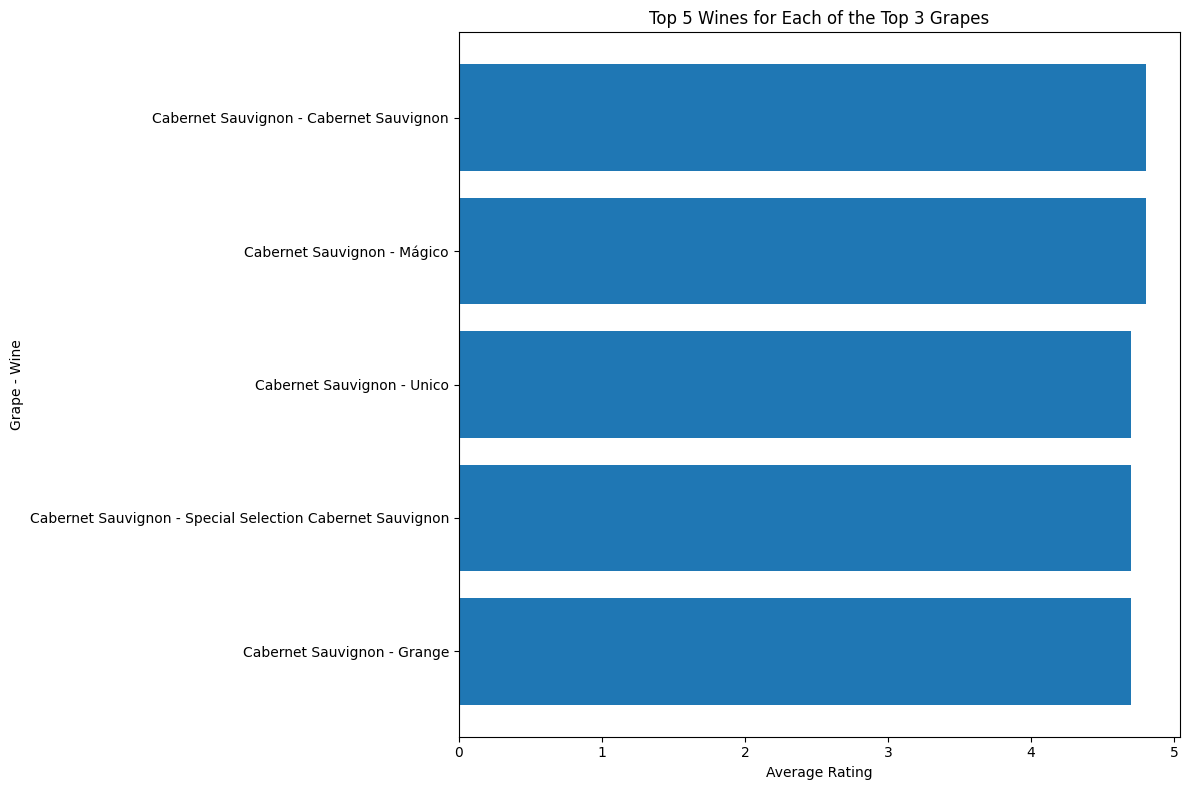

In [11]:
q5_labels = [f"{row[0]} - {row[1]}" for row in q5_rows]
q5_ratings = [row[3] for row in q5_rows]

plt.figure(figsize=(12, 8))
plt.barh(q5_labels, q5_ratings)
plt.gca().invert_yaxis()
plt.title("Top 5 Wines for Each of the Top 3 Grapes")
plt.xlabel("Average Rating")
plt.ylabel("Grape - Wine")
plt.tight_layout()
plt.show()

### Interpretation

This analysis highlights wines associated with globally common grape-producing markets.  
Although the wine-to-grape assignment is approximate, the result is still useful for identifying **globally accessible wine profiles** supported by strong ratings.

### Methodology

- The most common grapes were determined using the `most_used_grapes_per_country` table by aggregating grape frequency across all countries.
- Wines were linked to countries through the `regions` table.
- Each wine was then associated with grapes based on the **grape popularity within its country**.
- Wines were ranked using:
  - `ratings_average` (quality)
  - `ratings_count` (reliability)

- A ranking function was applied to select the **top 5 wines per grape**.

---

### Important Note

The dataset does not provide a direct relationship between individual wines and grape varieties.

As a result, this analysis uses a **country-level proxy**:
- Wines are associated with grapes that are commonly produced in their country of origin.

This approach allows us to approximate globally available wines while remaining consistent with the available data.

---

### Result

The final output shows, for each of the top 3 globally common grapes:
- The best rated wines
- Their country of origin
- Their rating and number of reviews

This provides a practical and data-driven selection of wines that are both **high quality** and **widely accessible worldwide**.

## 6-7 Country and Vintage Leaderboards

### Business question
Create a visual leaderboard showing:
- average wine rating for each country
- average wine rating for vintages

### Approach
- Country ratings are computed from `wines`, linked to `countries` through `regions`
- Vintage ratings are computed directly from `vintages`

In [12]:
q6_columns, q6_rows = run_query("../queries/business_questions/06_country_leaderboard.sql")
show_results(q6_columns, q6_rows)

Columns: ['country_name', 'avg_rating']
--------------------------------------------------------------------------------
('Israël', 4.5)
('Allemagne', 4.5)
('États-Unis', 4.4905405405405405)
('Moldavie', 4.4799999999999995)
('Hongrie', 4.472727272727273)
('Afrique du Sud', 4.45909090909091)
('Australie', 4.458333333333333)
('France', 4.447129909365559)
('Espagne', 4.443617021276595)
('Portugal', 4.435714285714286)

Total rows: 17


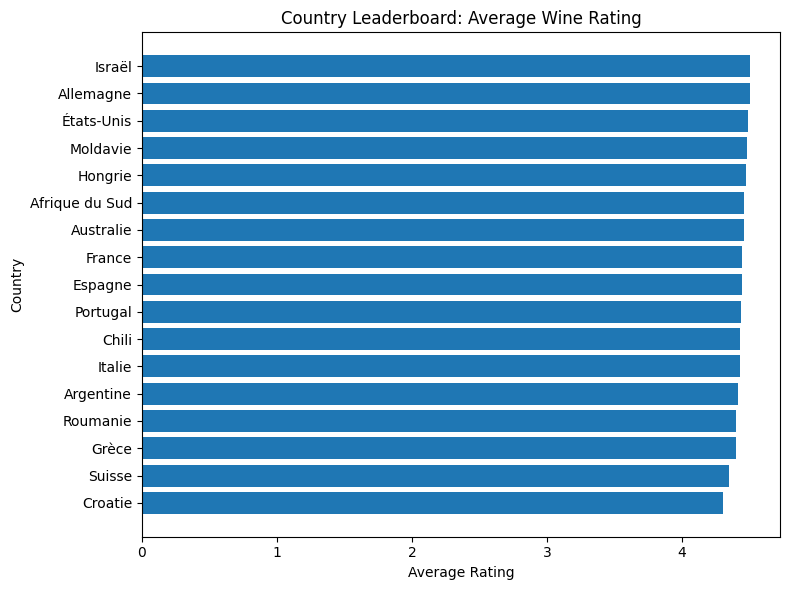

In [13]:
q6_country_names = [row[0] for row in q6_rows]
q6_avg_ratings = [row[1] for row in q6_rows]

plt.figure(figsize=(8, 6))
plt.barh(q6_country_names, q6_avg_ratings)
plt.gca().invert_yaxis()
plt.title("Country Leaderboard: Average Wine Rating")
plt.xlabel("Average Rating")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [14]:
q7_columns, q7_rows = run_query("../queries/business_questions/07_vintage_leaderboard.sql")
show_results(q7_columns, q7_rows)

Columns: ['vintage_year', 'avg_rating']
--------------------------------------------------------------------------------
(1955, 4.800000000000001)
(1962, 4.7)
(1959, 4.7)
(1929, 4.7)
(1999, 4.613636363636363)
(1965, 4.6)
(1910, 4.6)
(1968, 4.55)
(1977, 4.5)
(1975, 4.5)

Total rows: 69


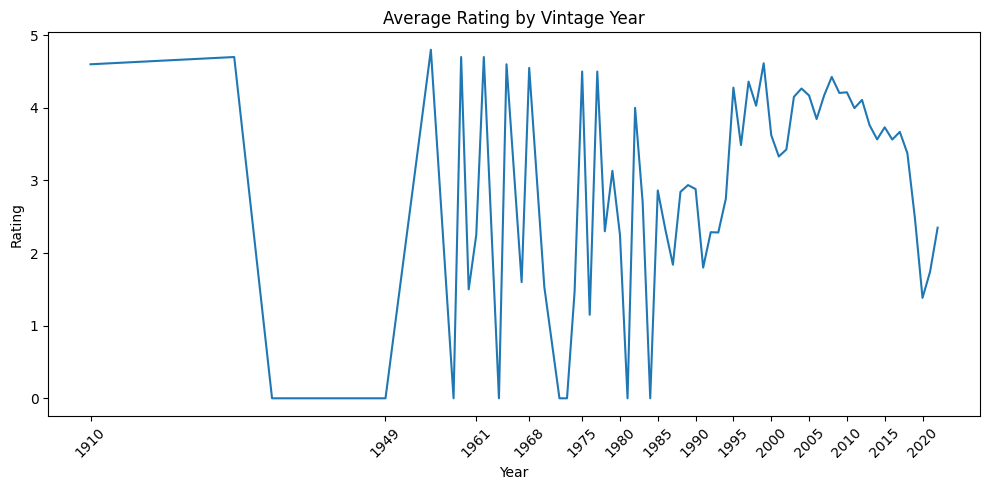

In [15]:
years = []
ratings = []

for row in q7_rows:
    if str(row[0]).isdigit():
        years.append(int(row[0]))
        ratings.append(row[1])

years, ratings = zip(*sorted(zip(years, ratings)))

plt.figure(figsize=(10, 5))
plt.plot(years, ratings)
plt.title("Average Rating by Vintage Year")
plt.xlabel("Year")
plt.ylabel("Rating")
plt.xticks(years[::5], rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

The country leaderboard highlights which wine-producing countries achieve the strongest average ratings.  
The vintage leaderboard adds a time perspective, showing how quality changes across years and helping identify strong historical vintages.

## 8. Additional Insights

To complement the core business questions, three extra insights were explored:
1. rating vs popularity
2. country engagement
3. flavor keyword popularity

### 8.A Rating vs Popularity
This examines whether highly rated wines also tend to receive many reviews.

In [16]:
q8a_columns, q8a_rows = run_query("../queries/business_questions/08_insight1_rating_vs_popularity.sql")
show_results(q8a_columns, q8a_rows)

Columns: ['name', 'ratings_average', 'ratings_count']
--------------------------------------------------------------------------------
('Cabernet Sauvignon', 4.6, 157944)
('Brut Champagne', 4.6, 146377)
('Tignanello', 4.5, 142513)
('Sassicaia', 4.6, 107646)
('60 Sessantanni Old Vines Primitivo di Manduria', 4.5, 94289)
('Costasera Amarone della Valpolicella Classico', 4.3, 93397)
('ARTEMIS Cabernet Sauvignon', 4.4, 81351)
('Amarone della Valpolicella Classico', 4.3, 77515)
('Opus One', 4.6, 77053)
('Pauillac (Premier Grand Cru Classé)', 4.6, 73615)

Total rows: 20


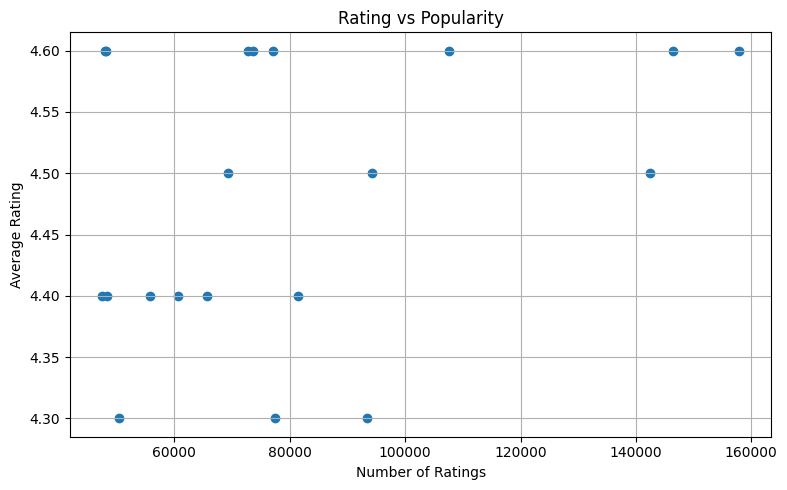

In [17]:
q8a_ratings = [row[1] for row in q8a_rows]
q8a_review_counts = [row[2] for row in q8a_rows]

plt.figure(figsize=(8, 5))
plt.scatter(q8a_review_counts, q8a_ratings)
plt.title("Rating vs Popularity")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:**  
The most reviewed wines also tend to have high ratings, suggesting that strong quality often translates into broad popularity.  
At the same time, a few less-reviewed wines still achieve excellent ratings, indicating hidden opportunities.

### 8.B Countries with High Engagement
This measures which countries generate the most user review activity.

In [18]:
q8b_columns, q8b_rows = run_query("../queries/business_questions/08_insight2_countries_with_high_engagement.sql")
show_results(q8b_columns, q8b_rows)

Columns: ['country_name', 'avg_rating', 'total_reviews']
--------------------------------------------------------------------------------
('Italie', 4.430026109660575, 2135839)
('France', 4.447129909365559, 2124809)
('États-Unis', 4.4905405405405405, 834263)
('Espagne', 4.443617021276595, 746710)
('Argentine', 4.417391304347826, 283673)
('Chili', 4.43125, 159256)
('Portugal', 4.435714285714286, 62454)
('Afrique du Sud', 4.45909090909091, 59995)
('Australie', 4.458333333333333, 52138)
('Hongrie', 4.472727272727273, 30564)

Total rows: 17


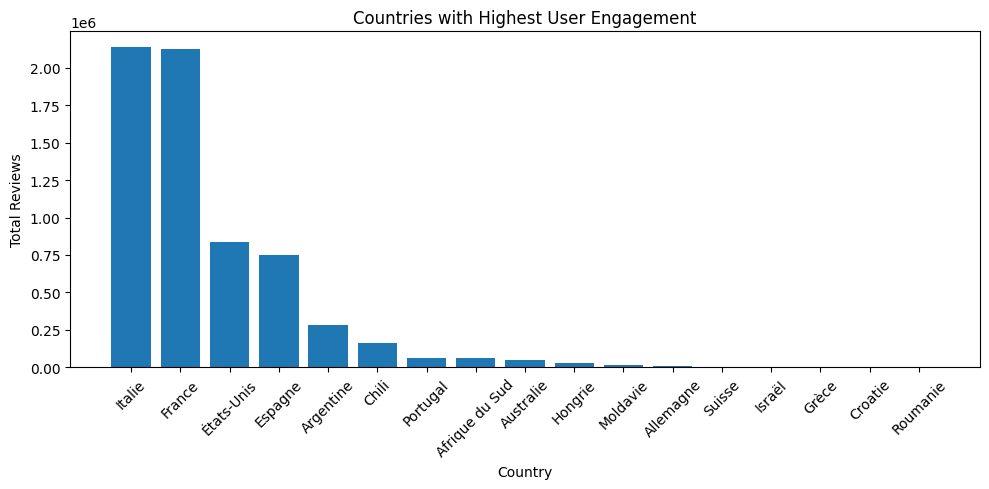

In [19]:
q8b_country_names = [row[0] for row in q8b_rows]
q8b_total_reviews = [row[2] for row in q8b_rows]

plt.figure(figsize=(10, 5))
plt.bar(q8b_country_names, q8b_total_reviews)
plt.title("Countries with Highest User Engagement")
plt.xlabel("Country")
plt.ylabel("Total Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:**  
Italy and France dominate total engagement, confirming their importance as mature and highly active wine markets.  
The United States also shows strong engagement combined with excellent average ratings.

### 8.C Flavor Keyword Popularity
This identifies the most frequently mentioned flavor keywords in the dataset.

In [20]:
q8c_columns, q8c_rows = run_query("../queries/business_questions/08_insight3_keyword_popularity.sql")
show_results(q8c_columns, q8c_rows)

Columns: ['name', 'total_mentions']
--------------------------------------------------------------------------------
('vanilla', 184356)
('tobacco', 174822)
('leather', 148724)
('oak', 96037)
('smoke', 80985)
('blackberry', 57601)
('cherry', 54103)
('cedar', 50396)
('plum', 49306)
('chocolate', 46607)

Total rows: 20


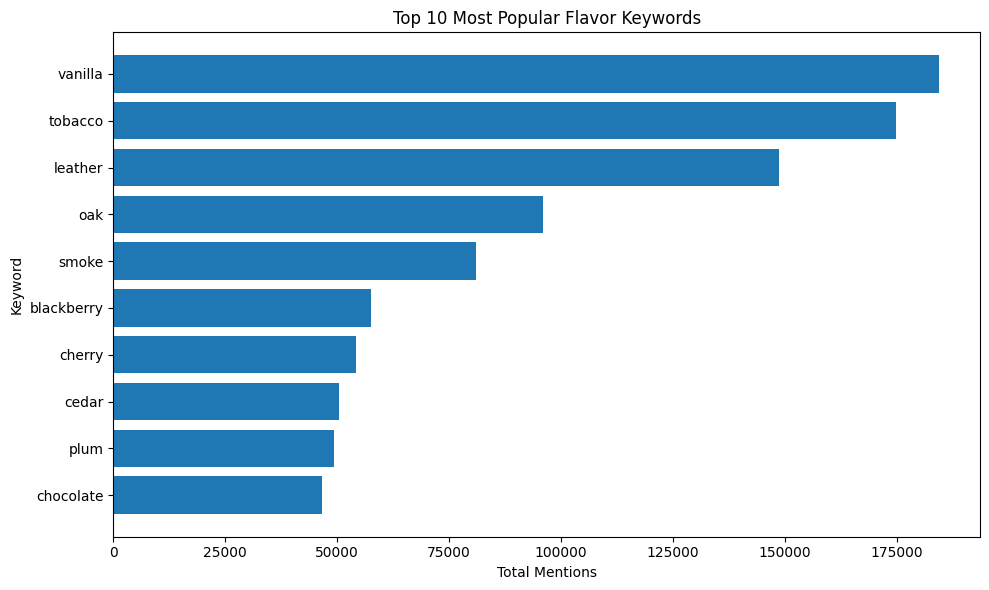

In [21]:
q8c_keyword_names = [row[0] for row in q8c_rows[:10]]
q8c_total_mentions = [row[1] for row in q8c_rows[:10]]

plt.figure(figsize=(10, 6))
plt.barh(q8c_keyword_names, q8c_total_mentions)
plt.gca().invert_yaxis()
plt.title("Top 10 Most Popular Flavor Keywords")
plt.xlabel("Total Mentions")
plt.ylabel("Keyword")
plt.tight_layout()
plt.show()

**Interpretation:**  
Keywords such as vanilla, tobacco, leather, oak, and smoke dominate the flavor landscape.  
This suggests strong user preference for complex, aged, and woody flavor profiles.

## Additional Insights — Exploration

### Objective

Identify meaningful patterns in user behavior, wine popularity, and taste preferences to complement the main analysis.

---

### Insight 1 — Rating vs Popularity

- The most reviewed wines (e.g. *Cabernet Sauvignon*, *Brut Champagne*, *Tignanello*) have both:
  - **high ratings (≈ 4.5–4.6)**
  - **very high number of reviews (70k–150k+)**

- This shows a **strong positive relationship between quality and popularity**

👉 **Conclusion:**  
Highly rated wines tend to attract more users, making them both **trusted and widely recognized** products.

---

### Insight 2 — Countries with High Engagement

- Countries with the highest total reviews:
  - **Italy (~2.1M reviews)**
  - **France (~2.1M reviews)**
  - **United States (~830k reviews)**

- All three also maintain **high average ratings (≈ 4.43–4.49)**

👉 **Conclusion:**  
Italy and France dominate both in **volume and engagement**, while the United States shows strong performance with slightly higher average ratings.

These countries represent **key markets with high user activity and strong product quality**.

---

### Insight 3 — Flavor Preferences

- Most popular flavor keywords:
  - **Vanilla (~184k mentions)**
  - **Tobacco (~174k)**
  - **Leather (~148k)**
  - **Oak (~96k)**
  - **Smoke (~80k)**

- Fruity notes (e.g. *blackberry*, *cherry*, *plum*) appear but are less dominant

👉 **Conclusion:**  
Users strongly prefer **complex, aged, and woody flavor profiles** over purely fruity ones.

This suggests a preference for:
- oak-aged wines  
- structured and mature taste profiles  

---

### Final Takeaway

These insights reveal that:

- **High-quality wines drive popularity**
- **Italy and France are dominant wine markets**
- **Consumers favor complex, mature flavor profiles**

Together, these findings provide a deeper understanding of both **market dynamics** and **consumer preferences**.

## 9. Nice-to-Have Additions

### 9.A Cabernet Sauvignon Recommendations
A VIP client asked for top Cabernet Sauvignon recommendations.

### 9.B Data and Schema Improvement Ideas
The analysis also highlights several ways to improve the dataset for future work.

### 9.A Cabernet Sauvignon Recommendations

In [26]:

q9_columns, q9_rows = run_query("../queries/business_questions/09_cabernet_sauvignon_top5.sql")
show_results(q9_columns, q9_rows)


Columns: ['wine_name', 'country_name', 'ratings_average', 'ratings_count']
--------------------------------------------------------------------------------
('Cabernet Sauvignon', 'États-Unis', 4.8, 2941)
('Special Selection Cabernet Sauvignon', 'États-Unis', 4.7, 41236)
('Cabernet Sauvignon', 'États-Unis', 4.6, 157944)
('Cabernet Sauvignon (Signature)', 'États-Unis', 4.6, 13730)
('CASK 23 Cabernet Sauvignon', 'États-Unis', 4.6, 9464)

Total rows: 5


### Interpretation:
### Cabernet Sauvignon — Top 5 Recommendations
To satisfy a VIP client interested in Cabernet Sauvignon, we identified the top performing wines based on average rating and number of reviews.

All top recommendations come from the United States, highlighting its dominance in producing highly rated Cabernet Sauvignon wines.

#### Notably:
The highest-rated wine reaches 4.8, indicating exceptional quality.
Some wines combine both high ratings and very large review counts (e.g. 157,944 reviews), making them both high-quality and reliable choices.

These wines represent safe, premium recommendations for a client seeking top Cabernet Sauvignon options.

### 9.B Suggested Data / Schema Improvements

- Add a direct **wine-to-grape relationship** table  
- Improve the completeness of **winery links**
- Standardize `year` values in `vintages` to avoid non-numeric values such as `N.V.`
- Add more explicit documentation for flavor and keyword structures
- Consider indexing frequently joined keys for faster query execution

## 10. Final Conclusion

This analysis shows that the wine market can be understood through a combination of:

- **quality** (`ratings_average`)
- **reliability / engagement** (`ratings_count`)
- **geography** (countries and regions)
- **taste preferences** (keywords and flavor groups)

Key takeaways:
- a clear top 10 wine shortlist can be built from quality and review volume
- the **United States** is the strongest country to prioritize on quality grounds
- winery performance can be viewed through complementary lenses: overall quality, popularity, and hidden-gem potential
- users strongly favor **complex, mature flavor profiles**
- Italy, France, and the United States dominate engagement and quality discussions

Overall, the findings support both **marketing decisions** and **customer recommendation strategies**.